# Customer Propensity Modeling

This notebook develops and evaluates machine-learning models to predict the
probability that a customer will subscribe to a term deposit.

The modeling workflow follows the pre-contact prediction framework defined
during EDA and is designed to prevent data leakage.


# Modeling Strategy

## Business Objective

Build a pre-contact customer propensity model that estimates the probability
that a customer will subscribe to a term deposit.

The model will be used to rank customers for targeted marketing outreach.

## Prediction Point

Predictions are assumed to be generated before the customer is contacted
during the current campaign.

## Target

The target variable is `y`, converted to a binary outcome:

- `1` = subscribed
- `0` = did not subscribe

## Feature Availability

The initial model will use information available before the current campaign
interaction.

### Included

- Customer demographics
- Financial characteristics
- Historical campaign information

### Excluded

- `duration` — generated during the current interaction
- `campaign` — current campaign contact count
- `day` and `month` — current campaign contact information

These exclusions are intended to prevent temporal or target leakage and ensure
that model evaluation reflects the intended pre-contact use case.

## Modeling Approach

The project will begin with an interpretable Logistic Regression baseline,
followed by tree-based models such as Random Forest and XGBoost.

All preprocessing will be fitted using the training data only and implemented
through a reproducible pipeline.

## Evaluation Strategy

Because the target is imbalanced, accuracy will not be used as the primary
evaluation metric.

Evaluation will include:

- ROC-AUC
- PR-AUC
- Precision
- Recall
- Precision@K
- Lift@K
- Probability calibration

Model performance will also be compared against the **11.7% baseline
subscription rate**.


In [3]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)


In [4]:
df = pd.read_csv("../data/bank-full.csv", sep=";")

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [5]:
target = "y"

features = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "pdays",
    "previous",
    "poutcome"
]

X = df[features].copy()
y = df[target].eq("yes").astype(int)

print(f"Number of observations: {len(X):,}")
print(f"Number of features: {len(features)}")
print(f"Positive class rate: {y.mean():.2%}")


Number of observations: 45,211
Number of features: 12
Positive class rate: 11.70%


In [6]:
excluded_features = ["duration", "campaign", "day", "month"]

present_excluded_features = [
    feature for feature in excluded_features
    if feature in X.columns
]

print("Excluded features found in X:", present_excluded_features)


Excluded features found in X: []


## Train/Test Split

The dataset is split into training and test sets before fitting any
preprocessing transformations or models.

A stratified split is used because the target is imbalanced. Stratification
preserves approximately the same positive-class proportion in both datasets.

The test set will remain untouched until final model evaluation.


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations: {len(X_test):,}")

print(f"\nTraining positive rate: {y_train.mean():.2%}")
print(f"Test positive rate: {y_test.mean():.2%}")


Training observations: 36,168
Test observations: 9,043

Training positive rate: 11.70%
Test positive rate: 11.70%


## Feature Types

The modeling dataset contains both numerical and categorical predictors.

Numerical variables will be evaluated for scaling and missing-value handling,
while categorical variables will be encoded using one-hot encoding.

Preprocessing will be implemented inside a `ColumnTransformer` and fitted
only on the training data to prevent information leakage from the test set.


In [8]:
numeric_features = X_train.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "str"]
).columns.tolist()

print("Numerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['age', 'balance', 'pdays', 'previous']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome']


## Preprocessing Pipeline

Numerical and categorical features require different preprocessing steps.

The preprocessing workflow will:

- Impute missing numerical values using the training-set median.
- Standardize numerical features for Logistic Regression.
- Impute missing categorical values using the most frequent category.
- One-hot encode categorical variables.
- Apply all transformations through a `ColumnTransformer`.

The preprocessing object will be combined with the model in a single
scikit-learn `Pipeline`. This ensures that preprocessing is learned only from
the training data and applied consistently to validation and test data.


In [9]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)


In [10]:
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


In [11]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)


## Baseline Model — Logistic Regression

Logistic Regression is used as the initial baseline because it provides an
interpretable reference model for binary classification.

The model will estimate the probability that a customer subscribes to the
term deposit.

Class weighting is used to account for the imbalanced target distribution.


In [12]:
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)


## Train Baseline Model

The Logistic Regression pipeline is fitted using the training data only.

The pipeline learns all preprocessing parameters and model coefficients from
the training set. The test set remains untouched until final evaluation.


In [13]:
logistic_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining

## Generate Predictions

The model produces both:

- A predicted class (`0` or `1`)
- A probability of subscription

Because this is a propensity-modeling problem, predicted probabilities are
more useful than class labels for ranking customers by likelihood of
subscription.


In [14]:
y_pred = logistic_model.predict(X_test)

y_proba = logistic_model.predict_proba(X_test)[:, 1]

print("Predicted classes:", y_pred[:10])
print("\nPredicted probabilities:", y_proba[:10])


Predicted classes: [0 0 0 0 0 1 0 1 1 1]

Predicted probabilities: [0.11473498 0.18199393 0.18265712 0.165862   0.47210924 0.60584965
 0.30823461 0.96323473 0.61583903 0.52591421]


In [15]:
pd.Series(y_proba).describe(
    percentiles=[0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99]
)


count    9043.000000
mean        0.434217
std         0.178561
min         0.086939
1%          0.129024
5%          0.177815
25%         0.292308
50%         0.428577
75%         0.545694
95%         0.721174
99%         0.949086
max         0.973237
dtype: float64

## Baseline Model Evaluation

Because the target is imbalanced, accuracy is not sufficient to evaluate
model quality.

ROC-AUC measures the model's ability to discriminate between subscribers and
non-subscribers across classification thresholds.

PR-AUC focuses more directly on performance for the positive class and is
particularly informative when the positive class is relatively uncommon.

These metrics evaluate the model's ranking ability without requiring us to
choose a single probability threshold.


In [16]:
roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print(f"ROC-AUC: {roc_auc:.4f}")
print(f"PR-AUC:  {pr_auc:.4f}")


ROC-AUC: 0.7428
PR-AUC:  0.3556


## Baseline Results

The initial Logistic Regression model provides a reference point for
subsequent model development.

| Model | ROC-AUC | PR-AUC |
|---|---:|---:|
| Logistic Regression | 0.7428 | 0.3556 |

The model demonstrates meaningful discriminatory and positive-class ranking
performance relative to the 11.7% subscription prevalence.

Probability calibration will be evaluated separately because class weighting
can affect the interpretation of predicted probabilities.


## Baseline Classification at 0.50 Threshold

Although propensity modeling primarily focuses on ranking customers by
predicted probability, the default 0.50 threshold provides a useful reference
for understanding classification behavior.

This threshold is not assumed to be the optimal business decision threshold.


In [17]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


[[5516 2469]
 [ 366  692]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.69      0.80      7985
           1       0.22      0.65      0.33      1058

    accuracy                           0.69      9043
   macro avg       0.58      0.67      0.56      9043
weighted avg       0.85      0.69      0.74      9043



### Baseline Interpretation

At the default 0.50 classification threshold, Logistic Regression achieves
65% recall and 22% precision for the positive class.

The model identifies a substantial proportion of actual subscribers, but the
relatively low precision results in a large number of false positives.

The overall accuracy of 69% is not considered a primary performance measure
because a majority-class classifier would achieve approximately 88.3% accuracy
given the observed class distribution.

This highlights the importance of evaluating the propensity model using
probability-ranking metrics such as PR-AUC, as well as business-oriented
metrics such as Precision@K and Lift@K.

The 0.50 threshold is treated only as a reference point rather than an
optimized business decision threshold.


## Random Forest

Random Forest is introduced as a nonlinear tree-based benchmark.

Unlike Logistic Regression, Random Forest can capture nonlinear relationships
and interactions between predictors without requiring them to be explicitly
specified.

The same train/test split will be used to ensure a consistent comparison with
the Logistic Regression baseline.


In [18]:
from sklearn.ensemble import RandomForestClassifier


In [19]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


### Train Random Forest

The Random Forest pipeline is fitted using the same training data used for
the Logistic Regression baseline.

The test set remains untouched until predictions are generated for evaluation.


In [20]:
random_forest_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining

In [21]:
rf_pred = random_forest_model.predict(X_test)

rf_proba = random_forest_model.predict_proba(X_test)[:, 1]

print("Predicted classes:", rf_pred[:10])
print("\nPredicted probabilities:", rf_proba[:10])


Predicted classes: [0 0 0 0 0 0 0 1 1 0]

Predicted probabilities: [0.02       0.06       0.         0.37333333 0.20666667 0.05666667
 0.23666667 0.90333333 0.71333333 0.25      ]


### Random Forest Evaluation

Random Forest is evaluated using the same metrics as the Logistic Regression
baseline.

ROC-AUC measures overall ranking discrimination, while PR-AUC focuses more
directly on identifying the minority positive class.


In [22]:
rf_roc_auc = roc_auc_score(y_test, rf_proba)
rf_pr_auc = average_precision_score(y_test, rf_proba)

print(f"Random Forest ROC-AUC: {rf_roc_auc:.4f}")
print(f"Random Forest PR-AUC:  {rf_pr_auc:.4f}")


Random Forest ROC-AUC: 0.7094
Random Forest PR-AUC:  0.2914


In [23]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc
    ],
    "PR-AUC": [
        pr_auc,
        rf_pr_auc
    ]
})

model_results


,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.742765,0.355614
1,Random Forest,0.709428,0.291447


### Random Forest Findings

The initial Random Forest benchmark achieved a ROC-AUC of 0.7094 and a PR-AUC
of 0.2914, both below the Logistic Regression baseline of 0.7428 ROC-AUC and
0.3556 PR-AUC.

This indicates that the additional nonlinear modeling capacity of Random
Forest did not improve generalization with the current feature representation
and hyperparameter configuration.

Random Forest will be retained as a benchmark rather than discarded, since
the current result does not establish that the algorithm is intrinsically
inferior. Hyperparameter tuning may produce different results, but model
selection will ultimately be based on consistent validation and business
relevant metrics rather than model complexity.


## XGBoost

XGBoost is introduced as a gradient-boosted tree benchmark for structured
tabular data.

Unlike the Random Forest benchmark, which builds trees independently,
gradient boosting builds trees sequentially to improve errors from previous
iterations.

XGBoost can capture nonlinear relationships and feature interactions while
remaining effective for high-dimensional tabular datasets.

The model will use the same training and test split as the previous models
to maintain a consistent evaluation framework.


In [24]:
import xgboost as xgb

print("XGBoost version:", xgb.__version__)


XGBoost version: 3.4.1


In [25]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)



(36168, 12)
(9043, 12)
(36168,)
(9043,)


In [26]:
negative_count = (y_train == 0).sum()
positive_count = (y_train == 1).sum()

scale_pos_weight = negative_count / positive_count

print(f"Negative cases: {negative_count:,}")
print(f"Positive cases: {positive_count:,}")
print(f"scale_pos_weight: {scale_pos_weight:.2f}")


Negative cases: 31,937
Positive cases: 4,231
scale_pos_weight: 7.55


In [27]:
xgb_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            xgb.XGBClassifier(
                n_estimators=300,
                max_depth=4,
                learning_rate=0.05,
                subsample=0.8,
                colsample_bytree=0.8,
                scale_pos_weight=scale_pos_weight,
                objective="binary:logistic",
                eval_metric="logloss",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)


### Train XGBoost

The XGBoost pipeline is fitted using the same training data and feature
preprocessing used for the previous models.

The held-out test set remains untouched until model evaluation.


In [28]:
xgb_model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](12,)","['age','job','marital',...,'pdays','previous','poutcome']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,12
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining

In [29]:
xgb_pred = xgb_model.predict(X_test)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

print("Predicted classes:", xgb_pred[:10])
print("\nPredicted probabilities:", xgb_proba[:10])


Predicted classes: [0 0 0 0 0 1 0 1 1 0]

Predicted probabilities: [0.18850355 0.19976792 0.1838168  0.25115913 0.4811679  0.5784432
 0.28798276 0.9420602  0.659889   0.4090466 ]


In [30]:
xgb_roc_auc = roc_auc_score(y_test, xgb_proba)
xgb_pr_auc = average_precision_score(y_test, xgb_proba)

print(f"XGBoost ROC-AUC: {xgb_roc_auc:.4f}")
print(f"XGBoost PR-AUC:  {xgb_pr_auc:.4f}")


XGBoost ROC-AUC: 0.7579
XGBoost PR-AUC:  0.3994


### Model Comparison Findings

The initial benchmark results show that XGBoost achieved the strongest
performance across both evaluation metrics, with a ROC-AUC of 0.7579 and
PR-AUC of 0.3994.

Logistic Regression provided a competitive and interpretable baseline, while
the initial Random Forest configuration produced lower performance on both
metrics.

The improvement from Logistic Regression to XGBoost suggests that nonlinear
relationships and feature interactions may provide additional predictive
signal in the customer data.

These results are treated as benchmark comparisons rather than final model
selection. Hyperparameter tuning will be performed using cross-validation on
the training data, while the held-out test set will remain reserved for final
evaluation.


In [31]:
xgb_classifier = xgb_model.named_steps["classifier"]

feature_importance = xgb_classifier.feature_importances_

print("Number of model features:", len(feature_importance))


Number of model features: 36


In [32]:
feature_names = (
    xgb_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

print("Number of feature names:", len(feature_names))
print(feature_names[:20])


Number of feature names: 36
['num__age' 'num__balance' 'num__pdays' 'num__previous' 'cat__job_admin.'
 'cat__job_blue-collar' 'cat__job_entrepreneur' 'cat__job_housemaid'
 'cat__job_management' 'cat__job_retired' 'cat__job_self-employed'
 'cat__job_services' 'cat__job_student' 'cat__job_technician'
 'cat__job_unemployed' 'cat__job_unknown' 'cat__marital_divorced'
 'cat__marital_married' 'cat__marital_single' 'cat__education_primary']


In [33]:
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": feature_importance
})

importance_df = importance_df.sort_values(
    by="importance",
    ascending=False
)

importance_df.head(20)


,feature,importance
34,cat__poutcome_success,0.390301
31,cat__contact_unknown,0.153456
25,cat__housing_no,0.058323
29,cat__contact_cellular,0.029211
17,cat__marital_married,0.027537
18,cat__marital_single,0.024111
27,cat__loan_no,0.023203
26,cat__housing_yes,0.020276
0,num__age,0.018402
2,num__pdays,0.016383


## XGBoost Feature Importance

Feature importance provides an initial view of which variables contribute most
to the model's predictions.

These importance scores describe the model's use of features and should not
be interpreted as causal effects. Additional interpretability analysis may be
used later to understand individual predictions and feature effects.


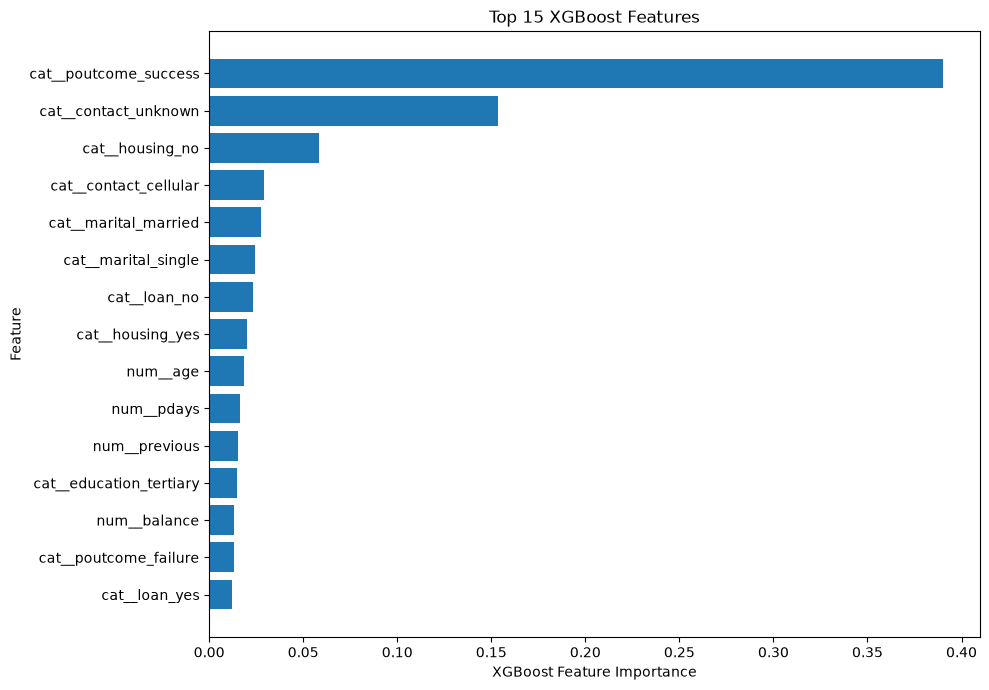

In [34]:
import matplotlib.pyplot as plt

top_features = importance_df.head(15).sort_values("importance")

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("XGBoost Feature Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")

plt.tight_layout()
plt.show()


In [35]:
print(
    importance_df[
        importance_df["feature"].str.contains("duration", case=False)
    ]
)


Empty DataFrame
Columns: [feature, importance]
Index: []


In [36]:
print("Features used for modeling:")
print(X.columns.tolist())


Features used for modeling:
['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'pdays', 'previous', 'poutcome']


### Feature Importance Findings

The XGBoost feature-importance analysis indicates that previous campaign
outcome is a major source of predictive signal, with `poutcome_success`
receiving the highest importance.

This is consistent with the EDA, where customers with a previous successful
campaign outcome had substantially higher subscription rates than other
groups.

Other influential features include contact method, housing status, marital
status, loan status, age, and previous campaign activity.

Feature importance reflects how the model uses variables for prediction and
should not be interpreted as a causal effect.

The `duration` feature is excluded from the modeling dataset because it
represents information generated during the current marketing interaction
and would not be available for a pre-contact customer-targeting decision.


### Feature Availability

The modeling dataset contains 12 customer and campaign-history features.

The `duration` variable was intentionally excluded because it represents the
duration of the current marketing interaction. Since the intended use case is
pre-contact customer targeting, this information would not be available when
the propensity score is generated.

Excluding `duration` helps align model development with the intended
deployment scenario and avoids relying on information generated during the
current interaction.



## XGBoost Hyperparameter Tuning

The initial XGBoost benchmark achieved a ROC-AUC of 0.7579 and PR-AUC of
0.3994.

Hyperparameter tuning will be performed using stratified cross-validation on
the training data. The held-out test set will remain untouched during tuning
and will be used only for final model evaluation.

The tuning process will focus on parameters controlling model complexity,
learning rate, and the number of boosting rounds.

PR-AUC will be emphasized because the positive class represents a minority of
the observations and the primary use case is ranking customers by propensity.
ROC-AUC will also be monitored as a complementary ranking metric.


In [37]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV


In [38]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)


In [39]:
param_grid = {
    "classifier__n_estimators": [200, 300, 500],
    "classifier__max_depth": [3, 4, 5],
    "classifier__learning_rate": [0.03, 0.05, 0.1],
}


In [40]:
xgb_grid = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    verbose=1
)


### Cross-Validated Hyperparameter Search

A 5-fold stratified cross-validation search is used to identify an XGBoost
configuration that generalizes well within the training data.

Average precision is used as the primary tuning metric because the positive
class is relatively rare and the business use case depends on effectively
ranking likely subscribers.


In [41]:
xgb_grid.fit(X_train, y_train)


Fitting 5 folds for each of 27 candidates, totalling 135 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__learning_rate': [0.03, 0.05, ...], 'classifier__max_depth': [3, 4, ...], 'classifier__n_estimators': [200, 300, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about mu

In [42]:
print("Best parameters:")
print(xgb_grid.best_params_)

print("\nBest cross-validation PR-AUC:")
print(f"{xgb_grid.best_score_:.4f}")


Best parameters:
{'classifier__learning_rate': 0.03, 'classifier__max_depth': 5, 'classifier__n_estimators': 200}

Best cross-validation PR-AUC:
0.3932


### Hyperparameter Tuning Findings

The 5-fold stratified cross-validation search selected a learning rate of
0.03, maximum tree depth of 5, and 200 boosting rounds.

The best mean cross-validation PR-AUC was 0.3932.

The held-out test set was not used during hyperparameter selection and remains
reserved for final model evaluation.

The cross-validation result is not directly compared with the original test
PR-AUC because they were obtained using different evaluation procedures.


In [43]:
refit=True


In [44]:
final_xgb_model = xgb_grid.best_estimator_


In [45]:
print(final_xgb_model)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'balance', 'pdays',
                                                   'previous']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='igno

In [46]:
final_xgb_proba = final_xgb_model.predict_proba(X_test)[:, 1]

final_xgb_pred = final_xgb_model.predict(X_test)


In [47]:
final_roc_auc = roc_auc_score(
    y_test,
    final_xgb_proba
)

final_pr_auc = average_precision_score(
    y_test,
    final_xgb_proba
)

print(f"Final XGBoost ROC-AUC: {final_roc_auc:.4f}")
print(f"Final XGBoost PR-AUC:  {final_pr_auc:.4f}")


Final XGBoost ROC-AUC: 0.7579
Final XGBoost PR-AUC:  0.4035


## Final Model Evaluation

The tuned XGBoost model achieved a ROC-AUC of 0.7579 and a PR-AUC of 0.4035
on the held-out test set.

Compared with the initial XGBoost benchmark, hyperparameter tuning produced a
modest improvement in PR-AUC from 0.3994 to 0.4035, while ROC-AUC remained
unchanged at 0.7579.

The results indicate that the initial XGBoost configuration was already
reasonably effective and that the hyperparameter search provided limited
additional performance improvement.

The final test set was evaluated only after model selection and tuning were
completed.


In [48]:
scored_test = pd.DataFrame({
    "actual": y_test.values,
    "propensity_score": final_xgb_proba
})

scored_test.head()


,actual,propensity_score
0,0,0.198382
1,0,0.194238
2,0,0.221567
3,0,0.234198
4,0,0.478229


In [49]:
scored_test = scored_test.sort_values(
    "propensity_score",
    ascending=False
).reset_index(drop=True)

scored_test.head(10)


,actual,propensity_score
0,1,0.964570
1,1,0.963831
2,1,0.962448
3,1,0.961659
4,1,0.961200
5,1,0.961106
6,1,0.960293
7,1,0.960264
8,0,0.959931
9,1,0.959782


In [50]:
scored_test["rank_percentile"] = (
    (scored_test.index + 1) / len(scored_test)
)


In [51]:
scored_test.head()


,actual,propensity_score,rank_percentile
0,1,0.964570,0.000111
1,1,0.963831,0.000221
2,1,0.962448,0.000332
3,1,0.961659,0.000442
4,1,0.961200,0.000553


In [52]:
top_10 = scored_test.head(
    int(len(scored_test) * 0.10)
)

print("Customers contacted:", len(top_10))
print("Subscribers captured:", top_10["actual"].sum())

precision_top_10 = top_10["actual"].mean()

total_subscribers = scored_test["actual"].sum()

recall_top_10 = (
    top_10["actual"].sum() / total_subscribers
)

print(f"Precision @ 10%: {precision_top_10:.2%}")
print(f"Recall @ 10%:    {recall_top_10:.2%}")


Customers contacted: 904
Subscribers captured: 404
Precision @ 10%: 44.69%
Recall @ 10%:    38.19%


In [53]:
overall_rate = scored_test["actual"].mean()

lift_top_10 = precision_top_10 / overall_rate

print(f"Overall subscription rate: {overall_rate:.2%}")
print(f"Top 10% subscription rate: {precision_top_10:.2%}")
print(f"Lift @ 10%: {lift_top_10:.2f}x")


Overall subscription rate: 11.70%
Top 10% subscription rate: 44.69%
Lift @ 10%: 3.82x


### Top 10% Targeting Results

When customers are ranked by predicted subscription propensity, the top 10%
of the test population contains 904 customers and 404 observed subscribers.

This segment achieves a 44.69% observed subscription rate compared with an
11.70% subscription rate across the overall test population, corresponding
to 3.82x lift.

The top 10% segment captures 38.19% of all observed subscribers while
representing only approximately 10% of the customer population.

These results indicate that the model can effectively concentrate customers
with higher observed subscription propensity into a relatively small
targeting segment.

Lift represents an association between model-ranked propensity and observed
outcomes; it should not be interpreted as a causal increase in conversion.


In [54]:
top_20 = scored_test.head(
    int(len(scored_test) * 0.20)
)

precision_top_20 = top_20["actual"].mean()

recall_top_20 = (
    top_20["actual"].sum()
    / scored_test["actual"].sum()
)

lift_top_20 = precision_top_20 / overall_rate

print("Customers contacted:", len(top_20))
print("Subscribers captured:", top_20["actual"].sum())
print(f"Precision @ 20%: {precision_top_20:.2%}")
print(f"Recall @ 20%:    {recall_top_20:.2%}")
print(f"Lift @ 20%:      {lift_top_20:.2f}x")


Customers contacted: 1808
Subscribers captured: 558
Precision @ 20%: 30.86%
Recall @ 20%:    52.74%
Lift @ 20%:      2.64x


In [55]:
def calculate_targeting_metrics(scored_data, percentages):
    results = []

    total_customers = len(scored_data)
    total_subscribers = scored_data["actual"].sum()
    overall_rate = scored_data["actual"].mean()

    for pct in percentages:
        n_customers = int(total_customers * pct)

        target_group = scored_data.head(n_customers)

        customers = len(target_group)
        subscribers = target_group["actual"].sum()

        precision = subscribers / customers
        recall = subscribers / total_subscribers
        lift = precision / overall_rate

        results.append({
            "Targeting %": pct,
            "Customers": customers,
            "Subscribers Captured": subscribers,
            "Precision": precision,
            "Recall": recall,
            "Lift": lift
        })

    return pd.DataFrame(results)


In [56]:
targeting_results = calculate_targeting_metrics(
    scored_test,
    [0.10, 0.20, 0.30, 0.40, 0.50]
)

targeting_results


,Targeting %,Customers,Subscribers Captured,Precision,Recall,Lift
0,0.1,904,404,0.446903,0.381853,3.819793
1,0.2,1808,558,0.308628,0.527410,2.637926
2,0.3,2712,677,0.249631,0.639887,2.133663
3,0.4,3617,775,0.214266,0.732514,1.831387
4,0.5,4521,837,0.185136,0.791115,1.582406


In [57]:
targeting_display = targeting_results.copy()

targeting_display["Targeting %"] = (
    targeting_display["Targeting %"] * 100
).round(0).astype(int).astype(str) + "%"

targeting_display["Precision"] = (
    targeting_display["Precision"] * 100
).round(2).astype(str) + "%"

targeting_display["Recall"] = (
    targeting_display["Recall"] * 100
).round(2).astype(str) + "%"

targeting_display["Lift"] = (
    targeting_display["Lift"].round(2).astype(str) + "x"
)

targeting_display


,Targeting %,Customers,Subscribers Captured,Precision,Recall,Lift
0,10%,904,404,44.69%,38.19%,3.82x
1,20%,1808,558,30.86%,52.74%,2.64x
2,30%,2712,677,24.96%,63.99%,2.13x
3,40%,3617,775,21.43%,73.25%,1.83x
4,50%,4521,837,18.51%,79.11%,1.58x


## Cumulative Lift Analysis

The cumulative lift curve evaluates how effectively the propensity model
concentrates observed subscribers within the highest-ranked customers.

As the targeting population expands, recall increases because more customers
are contacted. However, precision and lift decline as lower-propensity
customers are progressively included.

The curve provides a business-oriented view of the trade-off between campaign
reach and subscriber concentration.


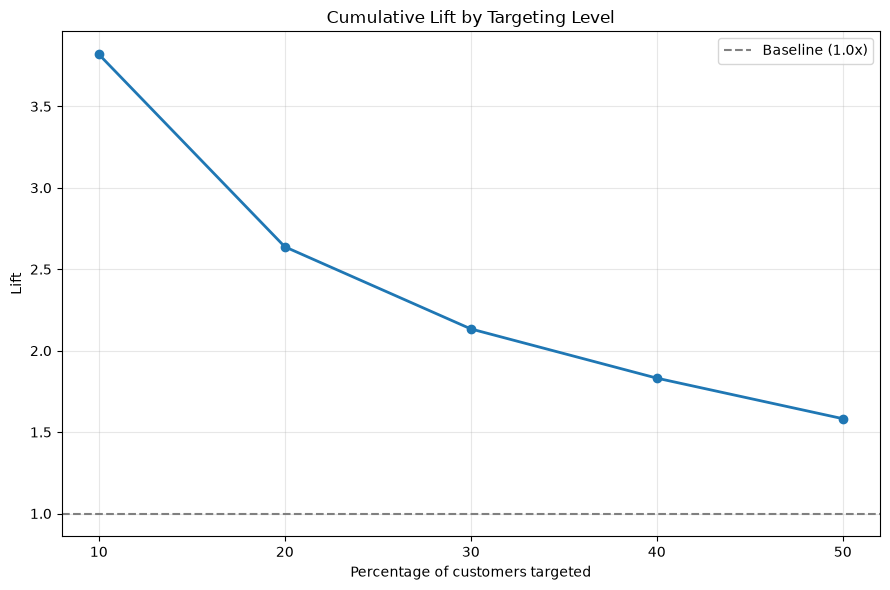

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

plt.plot(
    targeting_results["Targeting %"] * 100,
    targeting_results["Lift"],
    marker="o",
    linewidth=2
)

plt.axhline(
    y=1,
    color="gray",
    linestyle="--",
    label="Baseline (1.0x)"
)

plt.xlabel("Percentage of customers targeted")
plt.ylabel("Lift")
plt.title("Cumulative Lift by Targeting Level")

plt.xticks([10, 20, 30, 40, 50])
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


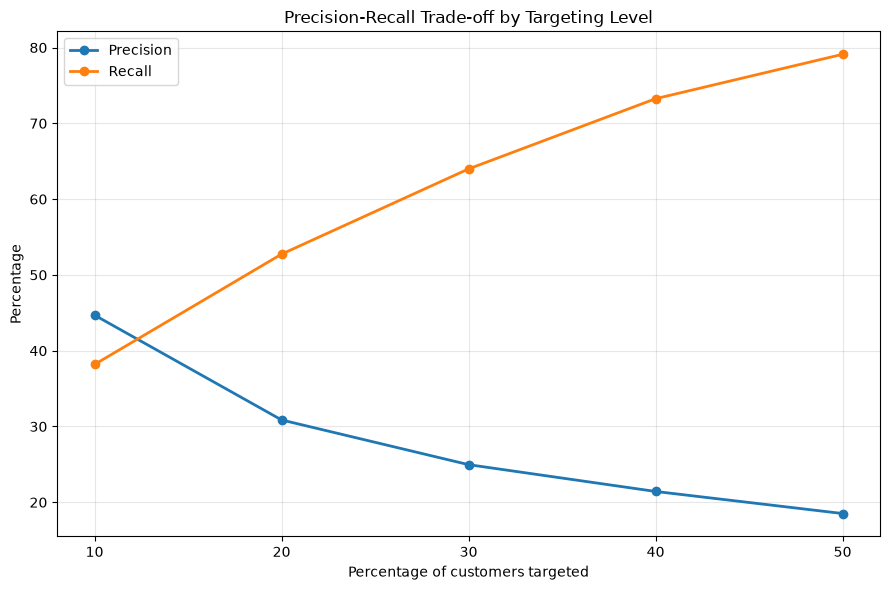

In [59]:
plt.figure(figsize=(9, 6))

plt.plot(
    targeting_results["Targeting %"] * 100,
    targeting_results["Precision"] * 100,
    marker="o",
    linewidth=2,
    label="Precision"
)

plt.plot(
    targeting_results["Targeting %"] * 100,
    targeting_results["Recall"] * 100,
    marker="o",
    linewidth=2,
    label="Recall"
)

plt.xlabel("Percentage of customers targeted")
plt.ylabel("Percentage")
plt.title("Precision-Recall Trade-off by Targeting Level")

plt.xticks([10, 20, 30, 40, 50])
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()


### Targeting Strategy Interpretation

The model demonstrates meaningful ranking ability across all evaluated
targeting levels.

At the top 10% targeting level, the model identifies 38.19% of observed
subscribers while targeting approximately 10% of customers, with 3.82x lift.

Expanding the target population to 20% increases subscriber recall to 52.74%,
while precision decreases from 44.69% to 30.86% and lift decreases from 3.82x
to 2.64x.

Further expansion continues to increase recall while reducing subscriber
concentration.

The appropriate targeting threshold should therefore be determined using
business constraints such as available campaign capacity, contact costs,
customer value, and the economics of conversion rather than model metrics
alone.


In [60]:
threshold = 0.50

threshold_pred = (
    final_xgb_proba >= threshold
).astype(int)

print("Predicted positives:", threshold_pred.sum())
print("Actual positives:", y_test.sum())


Predicted positives: 2492
Actual positives: 1058


In [61]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, threshold_pred))

print("\nPrecision:", f"{precision_score(y_test, threshold_pred):.2%}")
print("Recall:", f"{recall_score(y_test, threshold_pred):.2%}")
print("F1:", f"{f1_score(y_test, threshold_pred):.2f}")


Confusion Matrix:
[[6149 1836]
 [ 402  656]]

Precision: 26.32%
Recall: 62.00%
F1: 0.37


In [62]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    predictions = (
        final_xgb_proba >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Customers Selected": predictions.sum(),
        "Selection Rate": predictions.mean(),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results


,Threshold,Customers Selected,Selection Rate,Precision,Recall,F1
0,0.2,8060,0.891297,0.127543,0.971645,0.225488
1,0.3,6176,0.682959,0.151878,0.886578,0.259331
2,0.4,4139,0.457702,0.196907,0.770321,0.313642
3,0.5,2492,0.275572,0.263242,0.620038,0.369577
4,0.6,1361,0.150503,0.356356,0.458412,0.400992
5,0.7,764,0.084485,0.480366,0.346881,0.402854


In [63]:
threshold_display = threshold_results.copy()

threshold_display["Threshold"] = (
    threshold_display["Threshold"] * 100
).round(0).astype(int).astype(str) + "%"

threshold_display["Selection Rate"] = (
    threshold_display["Selection Rate"] * 100
).round(2).astype(str) + "%"

threshold_display["Precision"] = (
    threshold_display["Precision"] * 100
).round(2).astype(str) + "%"

threshold_display["Recall"] = (
    threshold_display["Recall"] * 100
).round(2).astype(str) + "%"

threshold_display["F1"] = threshold_display["F1"].round(2)

threshold_display


,Threshold,Customers Selected,Selection Rate,Precision,Recall,F1
0,20%,8060,89.13%,12.75%,97.16%,0.23
1,30%,6176,68.3%,15.19%,88.66%,0.26
2,40%,4139,45.77%,19.69%,77.03%,0.31
3,50%,2492,27.56%,26.32%,62.0%,0.37
4,60%,1361,15.05%,35.64%,45.84%,0.40
5,70%,764,8.45%,48.04%,34.69%,0.40


## Classification Threshold Analysis

The threshold analysis demonstrates the expected trade-off between precision
and recall.

Lower probability thresholds classify more customers as likely subscribers,
increasing recall while reducing precision. Higher thresholds produce a more
selective customer segment, increasing precision while reducing recall.

At a 70% threshold, 8.45% of customers are classified as positive, with
48.04% precision and 34.69% recall. At a 20% threshold, 89.13% of customers
are classified as positive, producing 12.75% precision and 97.16% recall.

For this propensity-ranking use case, probability thresholds and top-k
targeting serve different operational purposes. A probability threshold
selects customers based on an absolute predicted probability, while top-k
targeting selects a fixed proportion of the highest-ranked customers.

When campaign capacity is known in advance, top-k targeting provides a direct
way to control the number of customers selected.


## Model Comparison

Three classification approaches were evaluated using the same held-out test
set. ROC-AUC and PR-AUC were used as the primary model-level metrics because
the target variable is imbalanced.

The final XGBoost model provided the strongest overall ranking performance
among the evaluated models.


In [64]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "ROC-AUC": [
        0.7428,
        0.7094,
        0.7579,
        0.7579
    ],
    "PR-AUC": [
        0.3556,
        0.2914,
        0.3994,
        0.4035
    ]
})

model_comparison


,Model,ROC-AUC,PR-AUC
0,Logistic Regression,0.7428,0.3556
1,Random Forest,0.7094,0.2914
2,XGBoost,0.7579,0.3994
3,Tuned XGBoost,0.7579,0.4035


# Executive Summary

This project developed a machine-learning propensity model to identify
customers with a higher likelihood of subscribing to a marketing offer.

The analysis covered the complete modeling workflow, including exploratory
data analysis, feature preparation, model benchmarking, cross-validated
hyperparameter tuning, final evaluation, and business-oriented targeting
analysis.

### Key Results

- The dataset contains 45,211 customer records with an overall subscription
  rate of 11.7%.
- Logistic Regression achieved a ROC-AUC of 0.7428 and PR-AUC of 0.3556.
- Random Forest achieved a ROC-AUC of 0.7094 and PR-AUC of 0.2914.
- The final tuned XGBoost model achieved a ROC-AUC of 0.7579 and PR-AUC of
  0.4035 on the held-out test set.
- The top 10% of customers ranked by propensity achieved 44.69% precision,
  captured 38.19% of observed subscribers, and produced 3.82x lift relative
  to the overall subscription rate.
- Expanding targeting to the top 20% increased recall to 52.74% while
  reducing precision to 30.86% and lift to 2.64x.

### Business Interpretation

The model demonstrates an ability to concentrate customers with higher
observed subscription propensity toward the top of the ranking.

The targeting analysis illustrates the trade-off between campaign reach and
subscriber concentration. A smaller targeting population provides higher
precision and lift, while expanding the population increases subscriber
recall.

The appropriate targeting level should therefore be determined using
campaign capacity, contact costs, customer value, and conversion economics.

### Important Modeling Consideration

The `duration` feature was excluded because it represents the duration of the
current marketing interaction. It would not be available when generating a
pre-contact propensity score, so including it could introduce information
that would not exist at prediction time.

### Limitations

- The analysis evaluates predictive association rather than causal campaign
  impact.
- Historical campaign behavior may contain selection effects that influence
  observed outcomes.
- The appropriate operational targeting threshold depends on business
  economics and campaign capacity.
- Further validation on future or temporally separated data would be useful
  before production deployment.
- Campaign timing variables such as month may contain predictive signal, but
  were excluded from the final feature set to maintain a focus on customer
  characteristics and prior campaign behavior. Future experimentation could
  evaluate whether campaign timing improves out-of-sample performance without
  compromising the intended deployment scenario.



## Potential Next Steps

Future development could include:

- Temporal validation using a future holdout period.
- Probability calibration to improve the reliability of predicted
  subscription probabilities.
- Cost-sensitive targeting based on campaign economics.
- SHAP-based model interpretation for customer-level explanations.
- Monitoring for model drift and changes in customer behavior.
- A production scoring pipeline using AWS or Databricks.


In [65]:
print("Months:")
print(df["month"].value_counts())

print("\nMonth order:")
print(df["month"].unique())

print("\nDay range:")
print(df["day"].min(), "to", df["day"].max())


Months:
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64

Month order:
<ArrowStringArray>
['may', 'jun', 'jul', 'aug', 'oct', 'nov', 'dec', 'jan', 'feb', 'mar', 'apr',
 'sep']
Length: 12, dtype: str

Day range:
1 to 31


In [67]:
month_summary = (
    df.groupby("month")["y"]
    .agg(
        customer_count="count",
        subscription_rate=lambda x: (x == "yes").mean()
    )
)

month_summary["subscribers"] = (
    df.groupby("month")["y"]
    .apply(lambda x: (x == "yes").sum())
)

month_summary



,customer_count,subscription_rate,subscribers
month,,,
apr,2932,0.196794,577
aug,6247,0.110133,688
dec,214,0.467290,100
feb,2649,0.166478,441
jan,1403,0.101212,142
jul,6895,0.090935,627
jun,5341,0.102228,546
mar,477,0.519916,248
may,13766,0.067195,925


## Temporal Validation Consideration

The dataset contains campaign month and day variables, but the available
information does not establish that the observations represent a continuous
longitudinal customer timeline suitable for a chronological train/test split.

Subscription rates also vary substantially across campaign months, while the
number of observations per month is highly uneven.

Therefore, the primary evaluation uses a stratified train/test split to
preserve the positive-class distribution between training and test data.

A future production implementation should use temporally separated validation
data when reliable campaign dates and a genuine forward-looking prediction
scenario are available.
